<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/MD_C6_Ejercicios_Libro(SV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicio para la Sección 1**

**Objetivo**: Comprender cómo se distribuyen los datos antes de aplicar clustering.

**Instrucciones:**

    1. Genera un dataset con 4 grupos utilizando make_blobs.
    2. Visualiza los datos en un gráfico de dispersión.
    3. Reflexiona sobre qué técnica de clustering sería la más adecuada para estos datos.


# 1. Genera un dataset con 4 grupos utilizando make_blobs.

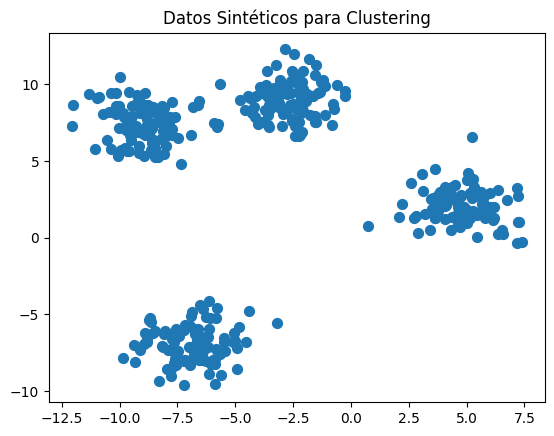

In [ ]:
# Creación de un Conjunto de Datos Sintético
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generar dataset sintético con 4 clusters
X, y = make_blobs(n_samples=400, centers=4, cluster_std=1.2, random_state=42)

# Visualizar los datos
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Datos Sintéticos para Clustering")
plt.show()

# 2. Visualiza los datos en un gráfico de dispersión.

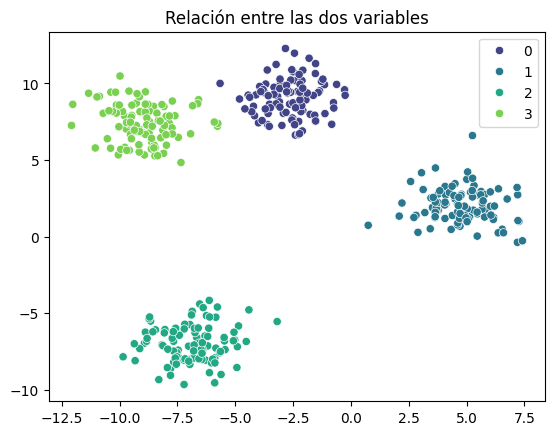

In [ ]:
# Define custom_palette for 4 clusters
custom_palette = sns.color_palette("viridis", n_colors=4)

# Visualiza los datos en un gráfico de dispersión
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette=custom_palette)
plt.title("Relación entre las dos variables")
plt.show()

# 3. Reflexiona sobre qué técnica de clustering sería la más adecuada para estos datos.

Podría usarse, K-Means o DBScan, ya que se observan cuatro grupos bien definidos.

Sin embargo, DBScan se ajusta mejor ya que: los cluster tienen una forma circular, binen definida, los grupos tienen casi la misma densidad, no se visualizan muchos outliers y la cantidad de clusters visaulmente es de cuatro grupos.

En conclusión, la técnica más adecuada sería K-Means, porque los datos presentan clusters compactos, bien definidos y separados. DBSCAN también funcionaría, pero sería más útil si hubiera outliers o grupos con formas irregulares.

## **Preguntas de Reflexión**

*1. ¿Cómo podríamos determinar automáticamente el número óptimo de clusters?*

DBScan (Density-Based Spatial Clustering of Applications with Noise), a diferencia de K-Means, no requiere especificar el número de clusters de antemano. DBScan identifica áreas de alta densidad separadas por regiones de baja densidad, detectando el número de grupos de forma automática basándose en la estructura de los datos.

*2. ¿Qué ventajas tiene visualizar los datos antes de aplicar clustering?*

Ofrece varias ventajas que permiten tomar mejores decisiones sobre el modelo a utilizar:
*   permite observar si los datos ya presentan agrupaciones, identificamos patrones naturales.
*   ayuda a entender cómo se distribuyen los puntos en el espacio es fundamental antes de elegir un algoritmo.
*   observando la forma de los datos, podemos decidir qué técnica es más apropiada. Si los datos forman grupos esféricos y bien definidos usamos K-Means. Si los datos muestran formas irregulares, no esféricas (como medias lunas) o contienen ruido, es preferible optar por DBScan.
*   facilita la identificación de ruido o puntos aislados. Esto es crucial, ya que algoritmos como K-Means tienen una alta sensibilidad a los outliers, mientras que otros como DBScan los manejan de forma más efectiva.
*   aunque existen métodos automáticos, una exploración visual inicial puede dar una idea intuitiva de cuántos clusters podrían existir en el conjunto de datos.

*3. ¿Qué pasaría si los clusters estuvieran muy superpuestos?*

Se producirían varias complicaciones tanto en la ejecución de los algoritmos como en la validación de los resultados:

*   las herramientas para medir la calidad del clustering mostrarían resultados pobres. El Coeficiente de Silhouette sería muy bajo (cercano a 0 o negativo), ya que esta métrica evalúa específicamente la separación entre clusters. Asimismo, el Índice de Davies-Bouldin (DBI) aumentaría, puesto que este índice busca una baja dispersión interna y una alta distancia entre grupos.
*   algoritmos como K-Means, que funcionan minimizando la distancia euclidiana hacia los centroides, tendrían problemas para definir a qué grupo pertenece un dato ubicado en la zona de solapamiento.
*   al intentar determinar 'K' mediante el Método del Codo o Silhouette, es probable que no se observe un "codo" claro o un pico distintivo en la curva, lo que dificulta la elección del número correcto de clusters.
*   dado que DBScan identifica clusters basándose en áreas de alta densidad separadas por regiones de baja densidad, una superposición significativa podría causar que el algoritmo no logre distinguir los grupos y los trate como una única masa de datos.

Si se detecta un clustering deficiente debido a la superposición o mala separación, se recomienda:
* probar otro algoritmo** de clustering que pueda adaptarse mejor a la estructura de los datos.
* ajustar los hiperparámetros, como el valor de 'K' en K-Means o los parámetros $\epsilon$ y *minPts* en DBScan.
* aplicar reducción de dimensionalidad (PCA) para intentar mejorar la separación de los datos antes de agruparlos.


# **Ejercicio para la Sección 2**

**Objetivo**: Aplicar K-Means a un dataset real y determinar el número óptimo de clusters.

**Instrucciones**:

1. Carga el dataset de pingüinos de Seaborn (sns.load_dataset("penguins")).
2. Selecciona variables numéricas (ejemplo: bill_length_mm, bill_depth_mm).
3. Usa el método del codo para determinar el mejor K.
4. Aplica K-Means y visualiza los clusters.
5. Explica qué insights puedes obtener de la segmentación.


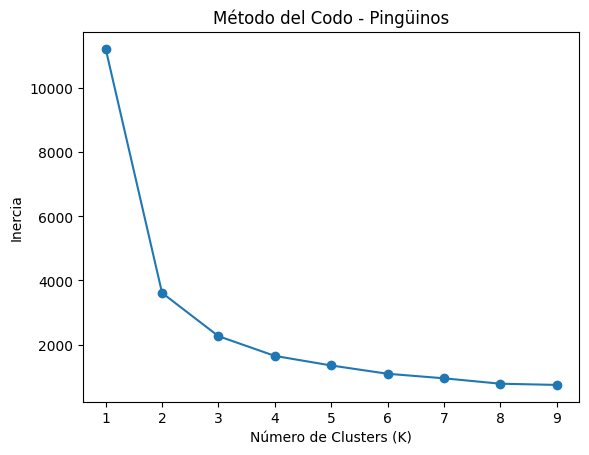

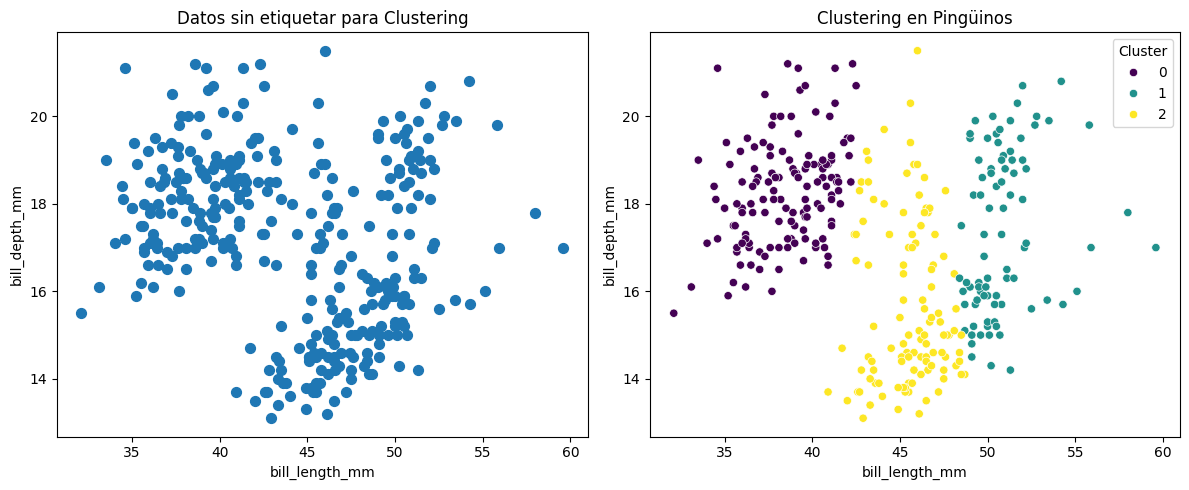

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1.Carga el dataset de pingüinos de Seaborn (sns.load_dataset("penguins")).
df = sns.load_dataset("penguins").dropna()
df_original = df.copy()

# 2. Selecciona variables numéricas (ejemplo: bill_length_mm, bill_depth_mm).
X = df[["bill_length_mm", "bill_depth_mm"]]

# 3. Método del Codo: para determinar el mejor valor de K
inercia = []
valores_k = range(1, 10)
for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X)
    inercia.append(kmeans.inertia_)

plt.plot(valores_k, inercia, marker="o", linestyle="-")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo - Pingüinos")
plt.show()

# 4. Aplicar K-Means con K óptimo
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df["Cluster"] = kmeans.fit_predict(X)

# Visualizar gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: datos sin etiquetas
axes[0].scatter(df_original["bill_length_mm"], df_original["bill_depth_mm"], s=50)
axes[0].set_xlabel("bill_length_mm")
axes[0].set_ylabel("bill_depth_mm")
axes[0].set_title("Datos sin etiquetar para Clustering")

# Gráfico 2: clustering
sns.scatterplot(x=df["bill_length_mm"], y=df["bill_depth_mm"],
                hue=df["Cluster"], palette="viridis", ax=axes[1])
axes[1].set_xlabel("bill_length_mm")
axes[1].set_ylabel("bill_depth_mm")
axes[1].set_title("Clustering en Pingüinos")

plt.tight_layout()
plt.show()

5. Explica qué insights puedes obtener de la segmentación.

La segmentación identifica tres grupos diferenciados de pingüinos según la longitud y profundidad del pico. Un grupo presenta picos cortos y profundos, otro picos largos y de mayor tamaño, y el tercero picos de longitud intermedia pero más delgados. La separación entre clusters es bastante clara, lo que indica que las variables utilizadas son útiles para distinguir patrones en los datos. Además, los grupos podrían representar distintas especies de pingüinos, ya que cada una posee características físicas particulares.

## **Preguntas de Reflexión**

*1. ¿Cómo afecta la selección de K a la segmentación de datos?*

La elección del número de clusters (K) es clave en la segmentación de datos porque determina cómo se agrupan los elementos y qué tan representativos serán los resultados. En algoritmos como K-Means, K define la cantidad exacta de grupos que se crearán. Un valor incorrecto puede generar clusters artificiales o poco útiles. A medida que K aumenta, la inercia disminuye, ya que los datos quedan más cerca de sus centroides, aunque un valor demasiado alto puede provocar sobreajuste. Además, K influye en la utilidad práctica de la segmentación, por ejemplo en marketing, donde define cuántos perfiles de clientes se identificarán. Un K bajo puede mezclar perfiles distintos, mientras que uno muy alto puede generar segmentos innecesarios. También afecta la separación y calidad de los grupos, evaluada mediante el Índice de Silhouette. Por eso, se recomienda usar métodos como el Método del Codo o Silhouette para seleccionar el valor óptimo de K.

*2. ¿Qué limitaciones tiene K-Means cuando los clusters no son esféricos?*

K-Means presenta limitaciones importantes cuando los clusters no tienen forma esférica, ya que utiliza la distancia euclidiana para agrupar los datos alrededor de centroides. El algoritmo asume que los grupos son circulares y de tamaño similar, por lo que fuerza la segmentación hacia formas redondeadas. Esto genera problemas cuando los datos poseen formas complejas, alargadas o irregulares. En esos casos, K-Means puede dividir un mismo grupo natural en varios clusters o unir puntos que no pertenecen al mismo conjunto. Como resultado, la segmentación obtenida no representa correctamente la estructura real de los datos. Además, es menos eficiente que algoritmos como DBScan, que pueden detectar clusters de formas arbitrarias mediante densidad. Por esta razón, se recomienda analizar visualmente los datos antes de aplicar K-Means y considerar algoritmos alternativos si los grupos no son esféricos.

*3. ¿Cómo podríamos mejorar los resultados de K-Means en datasets complejos?*

Para mejorar los resultados de K-Means en datasets complejos, es fundamental realizar un buen preprocesamiento de los datos. Se recomienda normalizar las variables con técnicas como MinMaxScaler o StandardScaler para evitar que algunas variables dominen el cálculo de distancias. También es importante limpiar datos nulos, inconsistentes y ruidos. Otra estrategia efectiva es aplicar reducción de dimensionalidad mediante PCA, lo que simplifica la estructura de los datos y mejora la separación de clusters. Además, se debe optimizar el valor de K utilizando métodos como el Método del Codo o el Índice de Silhouette. K-Means también es sensible a los outliers, por lo que identificarlos y tratarlos mejora la precisión de la segmentación. Si los clusters tienen formas complejas o arbitrarias, conviene considerar algoritmos alternativos como DBScan o SOM. En conclusión, la calidad del clustering depende tanto del algoritmo como de la preparación y validación de los datos.

# **Ejercicio para la Sección 3**

**Objetivo**: Aplicar DBScan a un dataset real y comparar los resultados con K-Means.

**Instrucciones**:

1. Carga el dataset de flores Iris (sns.load_dataset("iris")).
2. Selecciona dos características (sepal_length y sepal_width).
3. Aplica DBScan y visualiza los clusters.
4. Aplica K-Means y compara los resultados.
5. Explica qué diferencias observas entre ambos métodos.


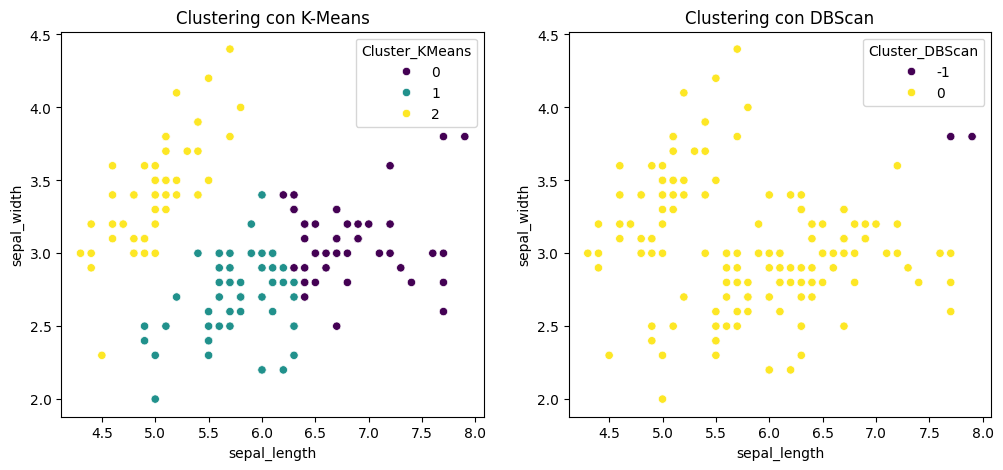

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN

# 1. Carga el dataset de flores Iris (sns.load_dataset("iris")).
df = sns.load_dataset("iris")

# 2. Selecciona dos características (sepal_length y sepal_width).
X = df[["sepal_length", "sepal_width"]].values

# Aplicar K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster_KMeans"] = kmeans.fit_predict(X)

# Aplicar DBScan
dbscan = DBSCAN(eps=0.5, min_samples=5)
#dbscan = DBSCAN(eps=0.3, min_samples=5)
df["Cluster_DBScan"] = dbscan.fit_predict(X)

# Visualizar
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=df["sepal_length"], y=df["sepal_width"],
                hue=df["Cluster_KMeans"], palette="viridis")
plt.title("Clustering con K-Means")

plt.subplot(1, 2, 2)
sns.scatterplot(x=df["sepal_length"], y=df["sepal_width"],
                hue=df["Cluster_DBScan"], palette="viridis")
plt.title("Clustering con DBScan")
plt.show()

## **Preguntas de Reflexión**

*1. ¿Cuántos clusters detectó DBScan en comparación con K-Means?*

DBScan detectó sólo un cluster, etiquetado como 0, mientras que K-Means establecío 3 clustering ya que le fué definido el valor K=3.

*2. ¿DBScan detectó puntos como outliers? ¿Por qué?*

DBScan detectó ruido o valores outliers, los cuales están etiquetados como -1.
El algoritmo identifica observaciones que no tienen suficientes vecinos cercanos dentro de una determinada distancia (radio ε). Es decir, esos puntos están demasiado aislados, no tienen vecinos cercanos, no pertenecen claramente a ningún grupo denso por lo cual se marca como "punto de ruido" (outlier).

*3. ¿Qué ventajas ofrece DBScan en este caso?*

* Puede detectar automáticamente puntos atípicos (outliers).
* No necesita definir previamente la cantidad de clusters, a diferencia de K-Means.
* Funciona bien cuando los grupos tienen formas irregulares.
* Se basa en densidad, por lo que puede separar mejor regiones densas de datos dispersos.
* Es más robusto frente al ruido que K-Means.

**Nota**: considerando que DBScan, agrupo la mayoría de los datos en un único cluster, se debería evaluar los parámetros elegido. "dbscan = DBSCAN(eps=0.3, min_samples=5)"

# **Ejercicio para la Sección 4**

**Objetivo**: Comparar diferentes algoritmos de clustering con métricas de evaluación.

**Instrucciones**:

1. Carga el dataset de diamantes (sns.load_dataset("diamonds")).
2. Selecciona variables numéricas (carat y price).
3. Aplica K-Means y DBScan.
4. Calcula el Coeficiente de Silhouette y el Davies-Bouldin Index para ambos.
5. Explica cuál algoritmo obtuvo la mejor segmentación.


In [ ]:
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 1. Cargar dataset de diamantes.
df = sns.load_dataset("diamonds")

# 2. Selecciona variables numéricas (carat y price).
X = df[["carat", "price"]].values[:1000]
#carat tiene valores pequeños (ej: 0.5, 1.2)
#price tiene valores enormes (cientos o miles)

# Escalar los datos antes de aplicar K-Means y DBScan.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplica K-Means y DBScan.
kmeans = KMeans(n_clusters=3, random_state=42)
labels_km = kmeans.fit_predict(X)

#dbscan = DBSCAN(eps=5000, min_samples=5)   ##eps.. muy grande
# después de escalar, usamos...
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

# 4. Calcula el Coeficiente de Silhouette y el Davies-Bouldin Index para ambos.
# Silhouette y Davies-Bouldin necesitan al menos 2 clusters.
silhouette_kmeans = silhouette_score(X, labels_km)
mask = labels_db != -1
silhouette_dbscan = silhouette_score(X[mask], labels_db[mask])

dbi_kmeans = davies_bouldin_score(X, labels_km)
dbi_dbscan = davies_bouldin_score(X, labels_db[mask])

print(f"Silhouette - K-Means: {silhouette_score(X, labels_km):.2f}")
print(f"Silhouette - DBScan:  {silhouette_score(X[mask], labels_db[mask]):.2f}")
print(f"Davies-Bouldin - K-Means: {davies_bouldin_score(X, labels_km):.2f}")
print(f"Davies-Bouldin - DBScan:  {davies_bouldin_score(X[mask], labels_db[mask]):.2f}")

Silhouette - K-Means: 0.97
Silhouette - DBScan:  0.98
Davies-Bouldin - K-Means: 0.12
Davies-Bouldin - DBScan:  0.05


# 5. Explica cuál algoritmo obtuvo la mejor segmentación.
Un mayor coeficiente de Silhouette indica clusters bien formados. --> DBScan

Un menor valor de Davies-Bouldin index significa clusters más denso y separados. --> DBScan

En conclusión, DBScan obtuvo la mejor segmentación.

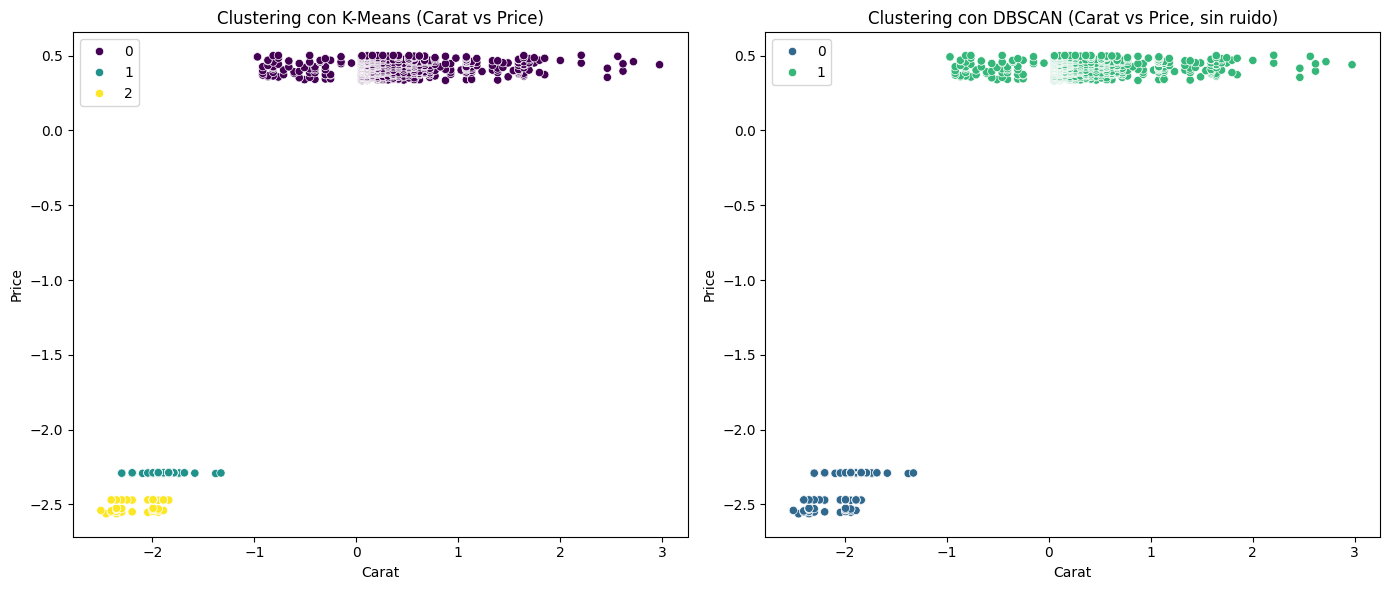

In [ ]:
plt.figure(figsize=(14, 6))

# Visualización de K-Means
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels_km, palette='viridis', legend='full')
plt.title('Clustering con K-Means (Carat vs Price)')
plt.xlabel('Carat')
plt.ylabel('Price')

# Visualización de DBSCAN
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_scaled[mask, 0], y=X_scaled[mask, 1], hue=labels_db[mask], palette='viridis', legend='full')
plt.title('Clustering con DBSCAN (Carat vs Price, sin ruido)')
plt.xlabel('Carat')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

## **Preguntas de Reflexión**

*1. ¿Cuál algoritmo obtuvo el mejor coeficiente de Silhouette?*

El mejor coeficiente de Silhouette lo obtuvo DBScan=0.98, comparado con K-Means=0.97
Como el coeficiente de Silhouette mide qué tan bien separados y compactos están los clusters, un valor más cercano a 1 indica una mejor segmentación.

*2. ¿El Davies-Bouldin Index confirma los resultados del Silhouette Score?*

Sí lo confirma. Los valores obtwenidos son DBScan=0.5 y K-Means=0.12
Los valores más bajos son mejores porque indican clusters más compactos y más separados entre sí.

*3. ¿En qué situaciones puede fallar cada métrica?*

Silhouette Score puede fallar cuando: los clusters tienen formas irregulares,
existen diferentes densidades, hay muchos outliers o cuando los grupos se superponen. Suele favorecer clusters compactos y esféricos, como los producidos por K-Means.

Davies-Bouldin puede dar resultados engañosos cuando: hay muchos outliers, existen clusters muy pequeños, los grupos tienen formas complejas o el algoritmo crea demasiados clusters. También puede verse afectado si los datos no están correctamente escalados.


# **Sección 5: Ejercicio Integrador Obligatorio**
Desarrollado en archivo separado.